# Homework 5 - Logistic Regression

## Your Name Here

Student Name: Leia Nayana Das

Student UT EID: lnd749

---

Partner Name: Javier Diaz de Sandi Viramontes

Partner UT EID:

---

Date Created: 10/05/2025

Date Last Modified: 10/06/2025

---

Totoal Points 20. 

In [88]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [89]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 (5 points)
We want to use logistic regerssion to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data. 

In [90]:
# classify target as No = 0 and Yes = 1
targetClass = {"Yes": 1, "No": 0}
heart_df = heart_df.replace({"Target": targetClass})

# prepare X and y
X = heart_df[["Age", "Sex", "Chol"]]
y = heart_df["Target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

C:\Users\User\AppData\Local\Temp\ipykernel_9848\2382619080.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heart_df = heart_df.replace({"Target": targetClass})


# Task 2 - (10 points)

Generate a logistic regression model using your training data. 

Print out the accuracy if your model. 

In [91]:
model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy (using .score): ", accuracy)

Model Accuracy (using .score):  0.6557377049180327


# Task 3 - (5 points)


Generate the classification report for your Logistic regresion model and interpret your results regarding precision, recall and f1-score. 


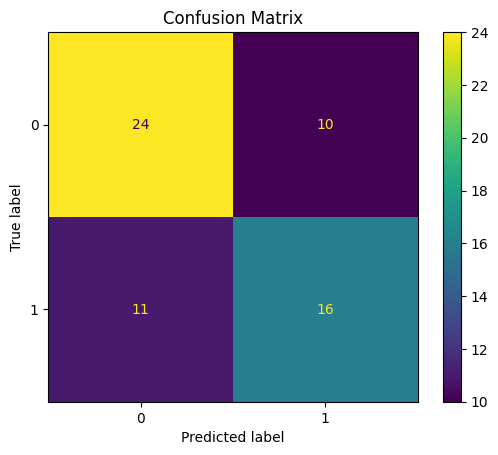

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        34
           1       0.62      0.59      0.60        27

    accuracy                           0.66        61
   macro avg       0.65      0.65      0.65        61
weighted avg       0.65      0.66      0.65        61



In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred=model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm) 
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# classification report
print(classification_report(y_test, y_pred))


#### Task 3 Results Interpretation

Recall that "0" means that the patient did not have heart disease and a "1" means that the patient did have heart disease. The classification report shows better metrics in precision, recall, and f-1 score for case "0", the patient not having heart disease. The recall report shows that the model correctly predicted that the patient had no heart disease 78% of the time, but only correctly predicted that patients did have heart disease 62% of the time. This means that the model is more likely to miss when a patient does have heart disease. The precision report shows that the model is more likely to show a false positive (predicting heart disease when there is none) than a false negative (predicting no heart disease when there is heart disease). The f1 scores reflect these differences in precision and recall, showing that the model performs better predicting when there's no heart disease than when there is.

# Task 4 - Optional Task (2 extra points)


Which other feature of your data can you use to improve your prediction? Build other models and improve your prediction. 


In [87]:
# original model accuracy for comparison
print("Original Model Accuracy (using .score): ", accuracy)

# include resting blood pressure as predicting factor
Xb = heart_df[["Age", "Sex", "Chol", "RestBP"]]
yb = heart_df["Target"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, train_size=0.8)

modelb = LogisticRegression()
modelb.fit(Xb_train, yb_train)

accuracyb = modelb.score(Xb_test, yb_test)
print("Model Accuracy with resting blood pressure (using .score): ", accuracyb)


# include max heart rate as predicting factor
Xn = heart_df[["Age", "Sex", "Chol", "MaxHR"]]
yn = heart_df["Target"]
Xn_train, Xn_test, yn_train, yn_test = train_test_split(Xn, yn, train_size=0.8)

modeln = LogisticRegression()
modeln.fit(Xn_train, yn_train)

accuracyn = modeln.score(Xn_test, yn_test)
print("Model Accuracy with max heart rate (using .score): ", accuracyn)

# include resting blood pressure and max heart rate as predicting factors
Xnb = heart_df[["Age", "Sex", "Chol", "MaxHR", "RestBP"]]
ynb = heart_df["Target"]
Xnb_train, Xnb_test, ynb_train, ynb_test = train_test_split(Xnb, ynb, train_size=0.8)

modelnb = LogisticRegression()
modelnb.fit(Xnb_train, ynb_train)

accuracynb = modelnb.score(Xnb_test, ynb_test)
print("Model Accuracy with max heart rate and resting blood pressure (using .score): ", accuracynb)

Original Model Accuracy (using .score):  0.7213114754098361
Model Accuracy with resting blood pressure (using .score):  0.6557377049180327
Model Accuracy with max heart rate (using .score):  0.6065573770491803
Model Accuracy with max heart rate and resting blood pressure (using .score):  0.8032786885245902
